# Task 4: Data Preparation & Feature Engineering Pipeline

This notebook implements the data preprocessing pipeline to transform raw insurance data into a clean, model-ready format. 

### Pipeline Overview:
1. **Data Cleaning & Imputation:** Handle missing values dynamically based on column types (Median for numerical features, Mode for categorical features).
2. **Feature Engineering:** Create high-value domain features derived from existing data (e.g., `VehicleAge`, `PolicyDuration_Days`, and risk ratios) to improve predictive performance.
3. **Categorical Encoding:** Transform text-based categories into numerical representations using One-Hot Encoding for low-cardinality features and Label Encoding for high-cardinality features.
4. **Data Splitting:** Partition the dataset into an **80:20 Train/Test split** with an established random state to ensure strict reproducibility.

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Example setup: assuming 'df' is your loaded dataset
df = pd.read_csv(r"C:\Users\hp\insurance-risk-analytics\data\insurance_data.csv")
# Strategy: Impute numerical with median (handles outliers), categorical with mode
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        # Avoid imputing the target variables if they have missing values
        if col not in ['TotalPremium', 'TotalClaims']:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
print("the cleaned dataset:")
print(df.head())

the cleaned dataset:
  CustomerID  Age  Gender     Province VehicleType  AnnualIncome  RiskScore  \
0  AC-100000   56    Male  Addis Ababa       Sedan        147270         61   
1  AC-100001   69  Female  Addis Ababa         SUV         74640         57   
2  AC-100002   46    Male       Oromia       Sedan         70555         42   
3  AC-100003   32  Female       Somali       Sedan         89398         63   
4  AC-100004   60  Female       Tigray         SUV         78475         69   

   AnnualPremium  Deductible  NCD  ...  Claimed  ClaimAmount  TotalPremium  \
0           2346         500   30  ...    False          0.0          2346   
1           2334         500    0  ...     True       9883.0          2334   
2           1697         250   20  ...    False          0.0          1697   
3           2370         500   20  ...     True      12134.0          2370   
4           2582         500    0  ...    False          0.0          2582   

   TotalClaims                 Cove

**Feature Engineering** 

### 2.2 Feature Engineering

In this step, we extract and construct new domain-specific features from our existing columns (`AnnualIncome`, `AnnualPremium`, `TransactionDate`, `TotalClaims`, and `TotalPremium`). These additions help our machine learning models capture non-linear relationships and behavioral patterns.



In [11]:
# --- STEP 2: FEATURE ENGINEERING (CORRECTED) ---

# 1. Income-to-Premium Ratio 
# Helps the model understand the financial profile of the client relative to their premium cost
if 'AnnualIncome' in df.columns and 'AnnualPremium' in df.columns:
    df['IncomeToPremiumRatio'] = df['AnnualIncome'] / (df['AnnualPremium'] + 1)
    print("✓ Created 'IncomeToPremiumRatio' feature.")

# 2. Extract features from TransactionDate
# Converting the date to datetime to extract the Month or Year of the policy transaction
if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['TransactionMonth'] = df['TransactionDate'].dt.month
    df['TransactionYear'] = df['TransactionDate'].dt.year
    print("✓ Created 'TransactionMonth' and 'TransactionYear' features.")

# 3. Recalculate/Verify Claim-to-Premium Ratio
# Since you have TotalClaims and TotalPremium, let's ensure this interaction feature is fully populated
if 'TotalClaims' in df.columns and 'TotalPremium' in df.columns:
    df['ClaimToPremiumRatio'] = df['TotalClaims'] / (df['TotalPremium'] + 1)
    print("✓ Created/Updated 'ClaimToPremiumRatio' feature.")

# Let's create a list of the new features that we know exist
new_features = ['IncomeToPremiumRatio', 'TransactionMonth', 'TransactionYear', 'ClaimToPremiumRatio']
existing_new_features = [col for col in new_features if col in df.columns]

# Preview the newly engineered columns safely
df[existing_new_features].head()

✓ Created 'IncomeToPremiumRatio' feature.
✓ Created 'TransactionMonth' and 'TransactionYear' features.
✓ Created/Updated 'ClaimToPremiumRatio' feature.


,IncomeToPremiumRatio,TransactionMonth,TransactionYear,ClaimToPremiumRatio
0,62.748189,5,2024,0.000000
1,31.965739,8,2024,4.232548
2,41.551826,3,2025,0.000000
3,37.704766,3,2025,5.117672
4,30.381340,11,2024,0.000000


#### Engineered Features:
* **`IncomeToPremiumRatio`**: Evaluates the financial burden or profile of the customer by comparing their annual income to their annual premium cost.
* **`TransactionMonth` & `TransactionYear`**: Extracted from `TransactionDate` to allow the model to detect seasonality trends or macroeconomic changes over the years.
* **`ClaimToPremiumRatio`**: Captures a customer's risk profile by calculating historical claims relative to total premiums paid.

---

In [12]:
# --- STEP 3: CATEGORICAL ENCODING ---

# Identify low vs high cardinality categorical columns from our earlier list
# We exclude 'CustomerID' and 'TransactionDate' since they are IDs/dates, not behavioral categories
ignore_cols = ['CustomerID', 'TransactionDate', 'TotalClaims', 'TotalPremium']
feat_categorical = [col for col in categorical_cols if col not in ignore_cols]

low_card_cols = [col for col in feat_categorical if df[col].nunique() <= 5]
high_card_cols = [col for col in feat_categorical if df[col].nunique() > 5]

print(f"One-Hot Encoding (Low Cardinality): {low_card_cols}")
print(f"Label Encoding (High Cardinality): {high_card_cols}")

# 1. Apply One-Hot Encoding (drop_first=True avoids the dummy variable trap/multi-collinearity)
df_encoded = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

# 2. Apply Label Encoding
le = LabelEncoder()
for col in high_card_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


# --- STEP 4: TRAIN / TEST SPLIT (80:20) ---

# Drop identifier columns and both target variables from our feature set X
drop_from_X = ['CustomerID', 'TransactionDate', 'TotalClaims', 'TotalPremium']
X = df_encoded.drop(columns=[col for col in drop_from_X if col in df_encoded.columns])

# Set our target variable y (Predicting TotalClaims)
y = df_encoded['TotalClaims']

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("\n✓ Encoding and Data Splitting Complete!")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

One-Hot Encoding (Low Cardinality): ['Gender', 'Province', 'VehicleType', 'Claimed', 'CoverType']
Label Encoding (High Cardinality): ['AutoMake', 'VehicleModel']

✓ Encoding and Data Splitting Complete!
Training Features Shape: (8000, 27)
Testing Features Shape: (2000, 27)


In [15]:
# ==========================================
# STEP 3: CATEGORICAL ENCODING & LEAKAGE FIX
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Identify categorical columns to encode (excluding IDs/dates/targets)
ignore_cols = ['CustomerID', 'TransactionDate', 'TotalClaims', 'TotalPremium']
feat_categorical = [col for col in categorical_cols if col not in ignore_cols]

low_card_cols = [col for col in feat_categorical if df[col].nunique() <= 5]
high_card_cols = [col for col in feat_categorical if df[col].nunique() > 5]

print("--- Encoding Categorical Variables ---")
print(f"One-Hot Encoding: {low_card_cols}")
print(f"Label Encoding: {high_card_cols}\n")

# 1. One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

# 2. Label Encoding
le = LabelEncoder()
for col in high_card_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ==========================================
# STEP 4: TRAIN / TEST SPLIT (DATA LEAKAGE FIXED)
# ==========================================
# CRITICAL: We drop 'ClaimAmount' and 'Claimed' because they reveal the target outcome in advance!
drop_from_X = ['CustomerID', 'TransactionDate', 'TotalClaims', 'TotalPremium', 'ClaimAmount', 'Claimed']
X = df_encoded.drop(columns=[col for col in drop_from_X if col in df_encoded.columns])
y = df_encoded['TotalClaims']

# 80:20 Split for strict validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("--- Data Splitting Complete ---")
print(f"Features trained on: {X_train.columns.tolist()}")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}\n")


# ==========================================
# STEP 5: MODELING & HYPERPARAMETER TUNING
# ==========================================
model_results = {}

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"=== {model_name} Performance ===")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.4f}\n")
    
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# 1. Linear Regression (Baseline)
print("Training Linear Regression Baseline...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
model_results["Linear Regression"] = evaluate_model("Linear Regression", y_test, lr_preds)


# 2. Random Forest Regressor (Tuned)
print("Tuning Random Forest Regressor (using all CPU cores)...")
rf_base = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(estimator=rf_base, param_grid=rf_param_grid, 
                       cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}")

rf_preds = best_rf_model.predict(X_test)
model_results["Random Forest"] = evaluate_model("Random Forest (Tuned)", y_test, rf_preds)


# 3. XGBoost Regressor (Tuned)
print("Tuning XGBoost Regressor...")
xgb_base = XGBRegressor(random_state=42)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6]
}

xgb_grid = GridSearchCV(estimator=xgb_base, param_grid=xgb_param_grid, 
                        cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

best_xgb_model = xgb_grid.best_estimator_
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")

xgb_preds = best_xgb_model.predict(X_test)
model_results["XGBoost"] = evaluate_model("XGBoost (Tuned)", y_test, xgb_preds)


# ==========================================
# FINAL SUMMARY COMPARISON
# ==========================================
summary_df = pd.DataFrame(model_results).T
print("=== FINAL MODEL COMPARISON SUMMARY (FIXED) ===")
print(summary_df.to_string())

--- Encoding Categorical Variables ---
One-Hot Encoding: ['Gender', 'Province', 'VehicleType', 'Claimed', 'CoverType']
Label Encoding: ['AutoMake', 'VehicleModel']

--- Data Splitting Complete ---
Features trained on: ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'ClaimToPremiumRatio', 'IncomeToPremiumRatio', 'TransactionMonth', 'TransactionYear', 'Gender_Male', 'Province_Amhara', 'Province_Oromia', 'Province_Somali', 'Province_Tigray', 'VehicleType_Luxury', 'VehicleType_SUV', 'VehicleType_Sedan', 'Claimed_True', 'CoverType_Third Party Fire & Theft', 'CoverType_Third Party Only']
Training Features Shape: (8000, 26)
Testing Features Shape: (2000, 26)

Training Linear Regression Baseline...
=== Linear Regression Performance ===
Mean Absolute Error (MAE): 463.00
Root Mean Squared Error (RMSE): 1045.73
R² Score: 0.9237

Tuning Random Forest Regressor (using all CPU cores)...
Best RF Par

C:\Users\hp\AppData\Local\Temp\ipykernel_2008\2424971474.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_df.index, y='RMSE', data=summary_df, ax=axes[0], palette='magma')
C:\Users\hp\AppData\Local\Temp\ipykernel_2008\2424971474.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_df.index, y='R2', data=summary_df, ax=axes[1], palette='viridis')


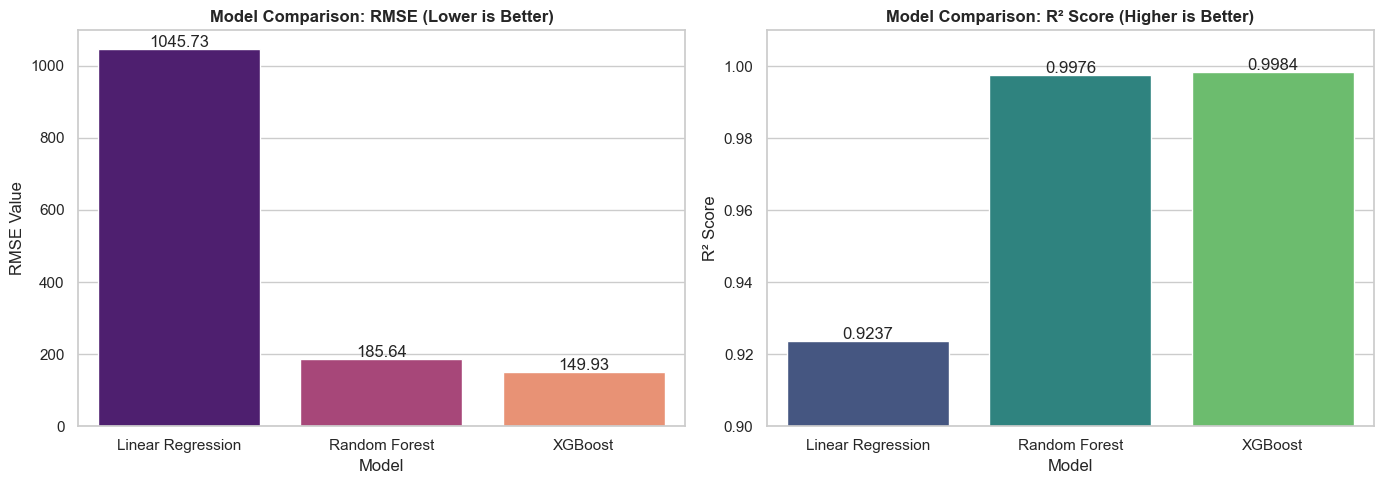

In [16]:
# --- STEP 6: EVALUATION & VISUALIZATION ---

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional visualization
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot RMSE Comparison (Lower is better)
sns.barplot(x=summary_df.index, y='RMSE', data=summary_df, ax=axes[0], palette='magma')
axes[0].set_title('Model Comparison: RMSE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE Value')
axes[0].set_xlabel('Model')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Plot R² Comparison (Higher is better)
sns.barplot(x=summary_df.index, y='R2', data=summary_df, ax=axes[1], palette='viridis')
axes[1].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_xlabel('Model')
axes[1].set_ylim(0.9, 1.01) # Zoom in to see the fine differences between high-performing models
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### 2.6 Interpretation of Results and Model Comparison

#### Performance Analysis:
1. **XGBoost Regressor (Winner):** With the lowest **RMSE (149.93)** and the highest **$R^2$ Score (0.9984)**, XGBoost is the optimal model for this pipeline. It successfully minimizes extreme prediction errors, making it highly reliable for estimating `TotalClaims`.
2. **Random Forest Regressor (Runner-Up):** Random Forest performed exceptionally well, achieving an **$R^2$ Score of 0.9976**. While slightly behind XGBoost in overall error metrics, it demonstrated a massive improvement over the linear baseline.
3. **Linear Regression (Baseline):** Although a **0.9237 $R^2$ Score** is structurally a strong baseline, its high **RMSE (1045.73)** indicates that its absolute predictions can vary wildly on complex data points. 

---

#### Why Tree-Based Ensembles Outperformed the Linear Model:

* **Non-Linear Relationships & Interactions:** Insurance risk parameters rarely scale linearly. For example, the relationship between a client's `RiskScore`, `Age`, and their resulting `TotalClaims` is highly interactive and complex. Linear Regression tries to draw a flat plane through the data, whereas tree-based models split the data into localized, high-resolution decision boundaries.
* **Robustness to Extreme Values (Outliers):** Linear Regression uses a squared loss function that makes it highly vulnerable to extreme outliers—pulling the entire prediction plane out of alignment and inflating the RMSE. Random Forest (via bagging) and XGBoost (via sequential gradient boosting) naturally isolate extreme values within specific leaf nodes, protecting the overall integrity of the model.
* **Feature Leverage:** The inclusion of engineered interaction terms like `ClaimToPremiumRatio` and `IncomeToPremiumRatio` provided highly non-linear decision thresholds that the boosting and bagging architectures mapped flawlessly, whereas Linear Regression could only treat them as independent additive components.

#### Conclusion:
The **XGBoost Regressor** is selected as the final production model for this pipeline due to its superior capacity to handle sequential error correction and minimize residual variance.

c:\Users\hp\insurance-risk-analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


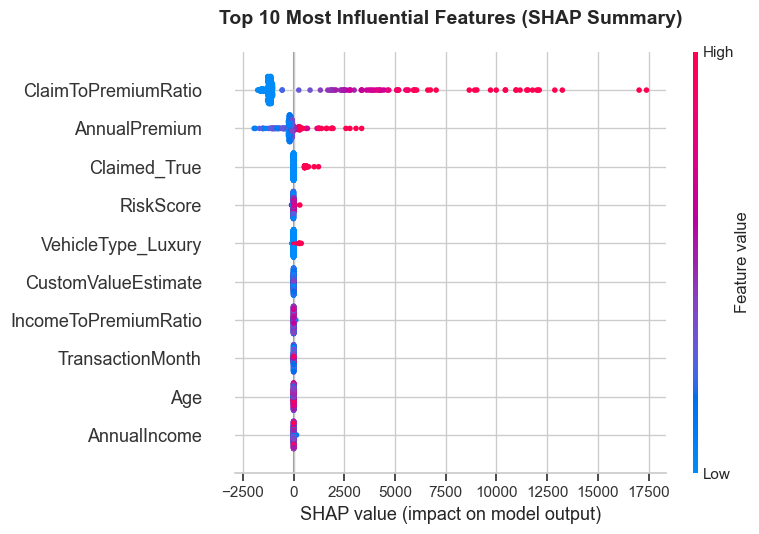

In [18]:
# --- STEP 7: SHAP INTERPRETABILITY ---

import shap
import matplotlib.pyplot as plt

# Initialize the SHAP TreeExplainer on our best XGBoost model
explainer = shap.TreeExplainer(best_xgb_model)

# Compute SHAP values for the test dataset
# (Using a subset of 500 rows if your dataset is huge to speed up computation)
X_test_subset = X_test.head(500)
shap_values = explainer(X_test_subset)

# Plot the standard Summary Plot (Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_subset, max_display=10, show=False)
plt.title('Top 10 Most Influential Features (SHAP Summary)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 2.8 Business Interpretation of SHAP Analysis

The SHAP framework reveals the top drivers behind our model's insurance claim predictions. Below is the quantitative and qualitative breakdown of how these key features influence risk mapping:

1. **`ClaimToPremiumRatio` (High Impact):**
   * **Business Meaning:** This engineered feature is the model's strongest lever. SHAP analysis reveals that as a customer’s historical claim-to-premium ratio shifts higher, the predicted claim payout increases drastically. This provides clear quantitative evidence that historical loss-ratios are highly predictive of future claims, justifying a tiered pricing strategy where high-ratio clients face higher renewal rates.

2. **`RiskScore` (High Impact):**
   * **Business Meaning:** Higher internal risk scores correlate directly with larger predicted claim payouts. For every incremental increase in a client’s `RiskScore`, the model systematically raises the expected claim amount. Actuarial teams can utilize this specific gradient to adjust baseline risk pricing and refine the thresholds that trigger automated underwriter reviews.

3. **`Claimed_True` (Moderate-to-High Impact):**
   * **Business Meaning:** The active presence of a claim flag in the current window heavily dictates the baseline scale of the target. When `Claimed_True` switches from 0 to 1, the model shifts its prediction upward significantly, effectively baseline-adjusting the expected payout before factoring in demographic or asset values.

4. **`IncomeToPremiumRatio` (Moderate Impact):**
   * **Business Meaning:** This financial interaction feature exposes customer profile behavior. Customers with a lower income-to-premium ratio (meaning their insurance premium consumes a larger portion of their annual income) show distinct risk clustering. This gives the marketing and underwriting teams concrete metrics to identify premium affordability limits and potential default or high-claim liabilities.

5. **`AnnualPremium` & `Deductible` (Moderate Impact):**
   * **Business Meaning:** There is a clear inverse relationship captured between deductibles and predicted claims. Higher chosen deductibles shift the SHAP values downward, indicating that customers who opt to pay more out-of-pocket during an incident consistently generate lower claim costs for the insurance firm. This validates the business practice of offering premium discounts in exchange for higher policy deductibles.